# **Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random
import glob as gb
import cv2
import tensorflow as tf
import keras
from google.colab import drive

# **Load Data From Drive**

In [ ]:
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Accessing Folders Of Train, Test and Evaluate**

In [ ]:
dataset_path = "/content/drive/MyDrive/NTI/data"

train_path = dataset_path + "/seg_train"
test_path = dataset_path + "/seg_test"
pred_path = dataset_path + "/seg_pred"

folders' names in train folder

In [ ]:
classes = os.listdir(train_path)

print(f"Classes {classes}")
print(f"Length : {len(classes)}")

Classes ['sea', 'street', 'glacier', 'mountain', 'forest', 'buildings']
Length : 6


# **Count Images In Each Class & Visualize It**

1. **Standard Color Names**

        'green', 'red', 'blue', 'cyan', 'magenta', 'yellow', 'black', 'white'

2. **Matplotlib / Tableau Named Colors**

        'tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan'

3. **CSS / HTML Color Names**

        'navy', 'teal', 'coral', 'crimson', 'gold', 'indigo', 'orchid', 'salmon', 'darkgreen', 'skyblue', etc.

4. **HEX Color Codes**

        '#4CAF50', '#FF5733', '#1E88E5'

5. **Single-Character Abbreviations**

        'b' (blue), 'g' (green), 'r' (red), 'c' (cyan), 'm' (magenta), 'y' (yellow), 'k' (black), 'w' (white)

6. **RGB / RGBA Tuples**

        (0.2, 0.7, 0.3) or (0.2, 0.7, 0.3, 0.8) (where the 4th value is transparency/alpha)

In [ ]:
classes_counts_train = {}

path_of_all_images = []
count_images_in_each_class = {}

for folder in os.listdir(train_path):
  path_of_all_images = gb.glob(pathname= str(train_path + '/' + folder + '/*.jpg'))
  count_images_in_each_class[folder] = len(path_of_all_images)
  print(f'for {folder} folder we have {len(path_of_all_images)} images')

classes_counts_train = count_images_in_each_class

for sea folder we have 90 images
for street folder we have 80 images
for glacier folder we have 70 images
for mountain folder we have 60 images
for forest folder we have 70 images
for buildings folder we have 70 images


In [ ]:
classes_counts_train

{'sea': 90,
 'street': 80,
 'glacier': 70,
 'mountain': 60,
 'forest': 70,
 'buildings': 70}

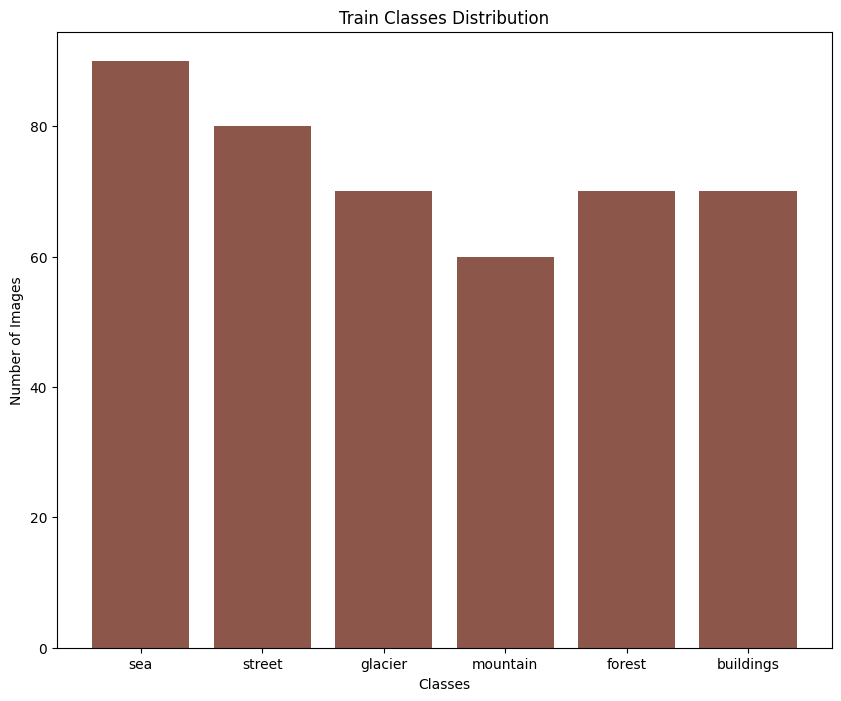

In [ ]:
plt.figure(figsize=(10,8))
plt.bar(list(count_images_in_each_class.keys()), list(count_images_in_each_class.values()), color= "tab:brown")
plt.title("Train Classes Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.show()

In [ ]:
classes_counts_test = {}

path_of_all_images = []
count_images_in_each_class = {}

for folder in os.listdir(test_path):
  path_of_all_images = gb.glob(pathname= str(test_path + '/' + folder + '/*.jpg'))
  count_images_in_each_class[folder] = len(path_of_all_images)
  print(f'for {folder} folder we have {len(path_of_all_images)} images')

classes_counts_test = count_images_in_each_class

for sea folder we have 80 images
for street folder we have 120 images
for buildings folder we have 100 images
for glacier folder we have 90 images
for mountain folder we have 90 images
for forest folder we have 80 images


In [ ]:
classes_counts_test

{'sea': 80,
 'street': 120,
 'buildings': 100,
 'glacier': 90,
 'mountain': 90,
 'forest': 80}

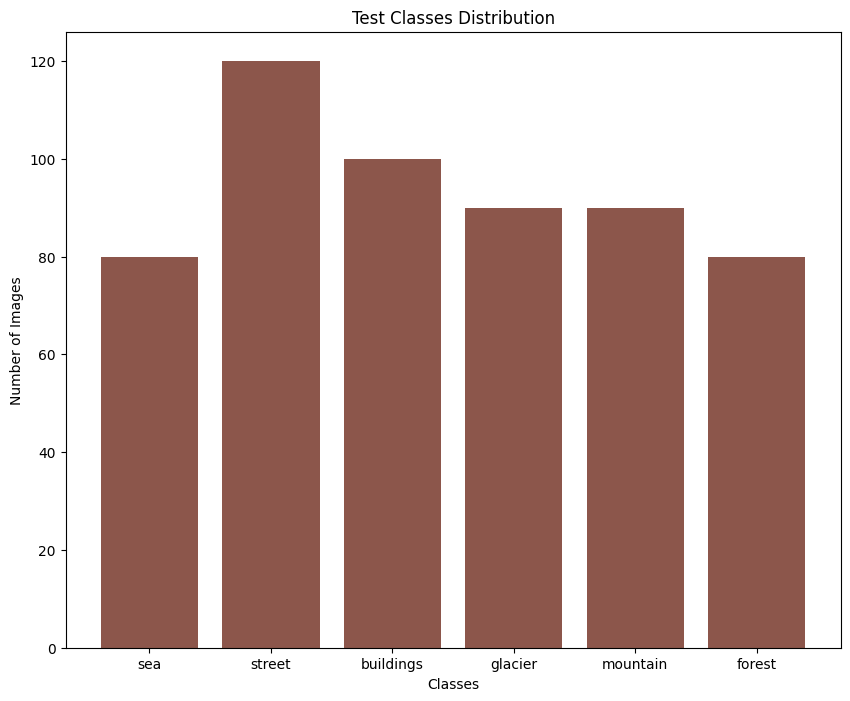

In [ ]:
plt.figure(figsize=(10,8))
plt.bar(list(count_images_in_each_class.keys()), list(count_images_in_each_class.values()), color= "tab:brown")
plt.title("Test Classes Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.show()

In [ ]:
path_of_images = gb.glob(pathname= str(pred_path + '/*.jpg'))
print(f'We have {len(path_of_images)} images')

We have 90 images


# **Count Images' Sizes**

In [ ]:
size = []
all_dir = [train_path, test_path]

for dir in all_dir:
  size = []
  for folder in os.listdir(dir):
    path_of_all_images = gb.glob(pathname= str(dir + '/' + folder + '/*.jpg'))
    for img in path_of_all_images:
      img = plt.imread(img)
      size.append(img.shape)
  print(f"For {'train' if 'train' in dir else 'test'} Folder")
  print(pd.Series(size).value_counts())
  print(f"Sizes of images : ")
  print(set(size))
  print(f"Number of Unique Sizes : {len(size)}", end = '\n\n')

For train Folder
(150, 150, 3)    438
(113, 150, 3)      1
(140, 150, 3)      1
Name: count, dtype: int64
Sizes of images : 
{(113, 150, 3), (150, 150, 3), (140, 150, 3)}
Number of Unique Sizes : 440

For test Folder
(150, 150, 3)    560
Name: count, dtype: int64
Sizes of images : 
{(150, 150, 3)}
Number of Unique Sizes : 560



# **Resizing & Visualizing**

In [ ]:
classes_ind = {'buildings':0 ,'forest':1,'glacier':2,'mountain':3,'sea':4,'street':5}

def get_name(n, class_indices):
    for k, v in classes_ind.items():
        if v == n:
            return k

In [ ]:
x_train = [] # new pics after resizing
y_train = [] # labels of each pic

# for dir in all_dir:
for folder in os.listdir(train_path):
  path_of_all_images = gb.glob(pathname= str(dir + '/' + folder + '/*.jpg'))
  for img in path_of_all_images:
    img = plt.imread(img)
    img = cv2.resize(img, (224,224))
    x_train.append(img)
    y_train.append(classes_ind[folder])

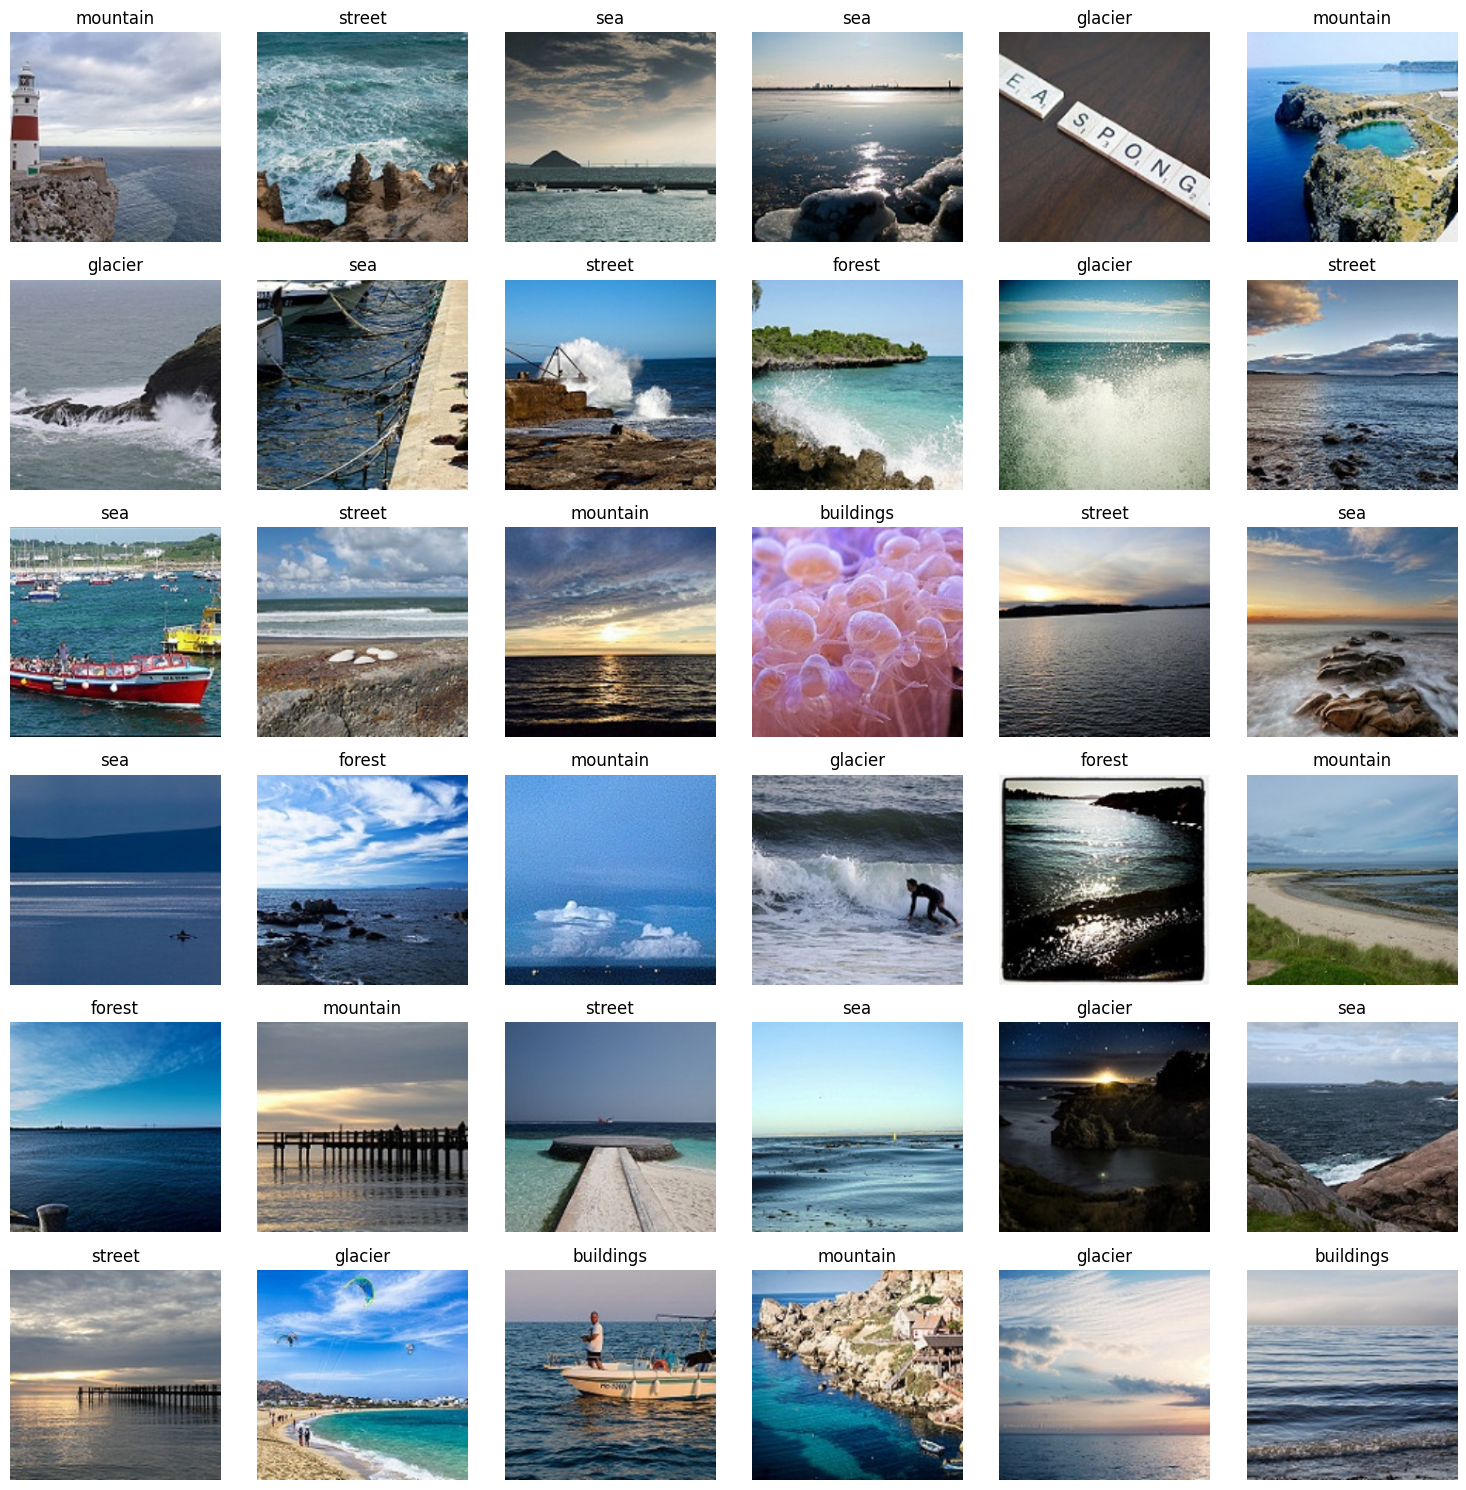

In [ ]:
plt.figure(figsize=(15,15))

random_indices = np.random.randint(0, len(x_train), 36)

for i,v in enumerate(random_indices):
  plt.subplot(6,6,i+1)
  plt.axis("off")
  plt.imshow(x_train[i])
  plt.title(get_name(y_train[v], classes_ind))

plt.tight_layout()
plt.show()

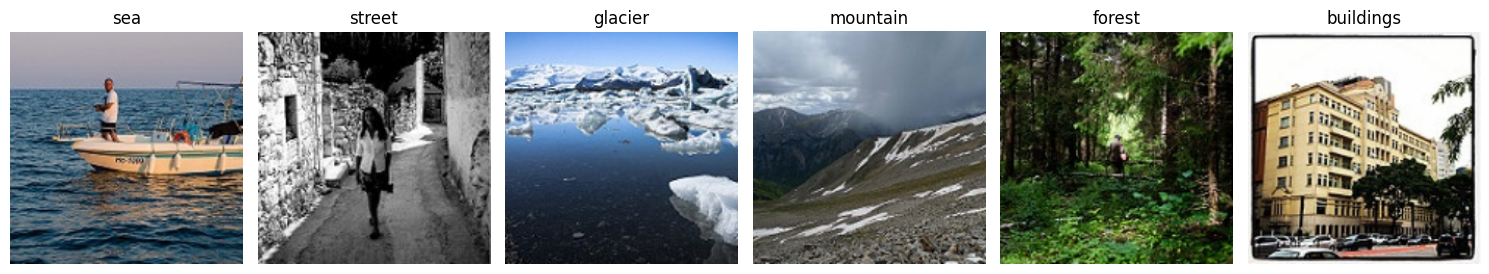

In [ ]:
plt.figure(figsize=(15, 5))

for i, folder in enumerate(classes):
    # target class index (0-5) for this specific folder
    target_class_id = classes_ind[folder]

    # indices in y_train that match the target class ID
    class_indices = [idx for idx, label in enumerate(y_train) if label == target_class_id]

    # Pick a random image index from this class
    random_idx = random.choice(class_indices)

    plt.subplot(1, len(classes), i + 1)
    plt.axis("off")
    plt.imshow(x_train[random_idx])
    plt.title(get_name(y_train[random_idx], classes_ind))

plt.tight_layout()
plt.show()

In [ ]:
x_test=[]
y_test=[]
for folder in os.listdir(test_path):
  image=gb.glob(pathname=str(test_path+"/"+folder+"/*.jpg"))
  for img in image:
    img= plt.imread(img)
    img=cv2.resize(img,(224,224))
    x_test.append(img)
    y_test.append(classes_ind[folder])

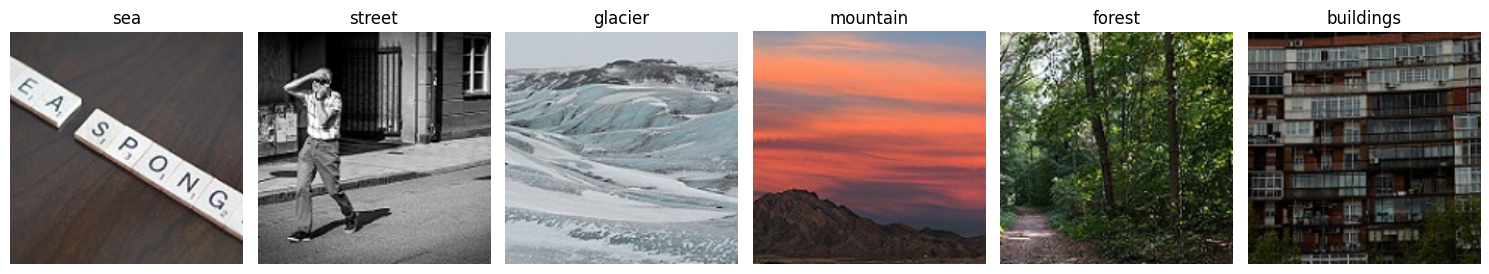

In [ ]:
plt.figure(figsize=(15, 5))

for i, folder in enumerate(classes):
    target_class_id = classes_ind[folder]

    class_indices = [idx for idx, label in enumerate(y_test) if label == target_class_id]

    random_idx = random.choice(class_indices)

    plt.subplot(1, len(classes), i + 1)
    plt.axis("off")
    plt.imshow(x_test[random_idx])
    plt.title(get_name(y_test[random_idx], classes_ind))

plt.tight_layout()
plt.show()

In [ ]:
x_pred=[]
image=gb.glob(pathname=str(pred_path+"/*.jpg"))
for img in image:
  img= plt.imread(img)
  img=cv2.resize(img,(224,224))
  x_pred.append(img)

# **Convert Into Numpy Array Type & Saving Dataset**

In [ ]:
type(x_train)

list

In [ ]:
x_train=np.array(x_train)
y_train=np.array(y_train)

x_test=np.array(x_test)
y_test=np.array(y_test)

x_pred=np.array(x_pred)

In [ ]:
save_path = f"{dataset_path}/resized_train_data.npz"

np.savez_compressed(
    save_path,
    x_train=x_train,
    y_train=y_train
)

In [ ]:
save_path = f"{dataset_path}/resized_test_data.npz"

np.savez_compressed(
    save_path,
    x_test=x_test,
    y_test=y_test
)

In [ ]:
save_path = f"{dataset_path}/resized_pred_data.npz"

np.savez_compressed(
    save_path,
    x_pred=x_pred
)

# **Building Our CNN Architecture**

This CNN architecture processes 224 x 224 x 3 RGB images through two convolutional/pooling feature extraction blocks before flattening the feature maps and classifying them into 6 classes via dense layers.

1. Feature Extraction (Conv2D & MaxPooling2D):
    - First Block: Learns low-level features (edges, textures) with 64 and 32 filters of size 3 x 3, followed by a 2 x 2 max pooling layer that downsamples the spatial resolution by half (from 220 x 220 to 110 x 110).
    - Second Block: Extracts higher-level patterns (shapes, object parts) with another set of 64 and 32 filters, followed by downsampling to 53 x 53

2. Flattening (Flatten):Converts the 3D tensor (53 x 53 x 32) into a 1D vector of size 89,888 (53 x 53 x 32) to feed into standard fully connected layers.
3. Classification (Dense):
    - Dense(128) & Dense(64): Fully connected layers using ReLU activation to combine features and learn non-linear decision boundaries.
    - Dense(6, activation="softmax"): Output layer producing a probability distribution across the 6 classes (values sum to 1.0).

In [ ]:
model= keras.models.Sequential(
    [
      # First Conv Layer: 64 filters of 3x3, extracts low-level features (edges/textures)
      # Output shape: (222, 222, 64)
        keras.layers.Conv2D(64,kernel_size=(3,3),activation="relu",input_shape=(224,224,3)),

      # Second Conv Layer: Refines features into 32 channel maps
      # Output shape: (220, 220, 32)
        keras.layers.Conv2D(32,kernel_size=(3,3),activation="relu"),
      # Max Pooling: Halves spatial dimensions to reduce computation and spatial invariance
      # Output shape: (110, 110, 32)
        keras.layers.MaxPooling2D(pool_size=(2,2)),

      # Third Conv Layer: Extracts higher-level patterns from downsampled features
      # Output shape: (108, 108, 64)
        keras.layers.Conv2D(64,kernel_size=(3,3),activation="relu"),

      # Fourth Conv Layer: Further refines mid-level features
      # Output shape: (106, 106, 32)
        keras.layers.Conv2D(32,kernel_size=(3,3),activation="relu"),
      # Max Pooling: Halves spatial dimensions again
      # Output shape: (53, 53, 32)
        keras.layers.MaxPooling2D(pool_size=(2,2)),

      # Flatten: Unrolls 3D feature tensor (53x53x32) into 1D vector (length = 89,888)
        keras.layers.Flatten(),
      # Dense Layer 1: Fully connected layer with 128 units for complex feature combinations
        keras.layers.Dense(128,activation="relu"),
      # Dense Layer 2: Fully connected layer with 64 units to condense features
        keras.layers.Dense(64,activation="relu"),
      # Output Layer: 6 neurons matching the 6 classes; Softmax outputs class probabilities
        keras.layers.Dense(6,activation="softmax")
    ]
)


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 222, 222, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 220, 220, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 110, 110, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 108, 108, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 106, 106, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 53, 53, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 89888)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │    11,505,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,571,654 (44.14 MB)

 Trainable params: 11,571,654 (44.14 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

# **Model Training**

In [ ]:
history = model.fit(x_train,y_train,epochs=3,batch_size=64,verbose=1)

Epoch 1/3
9/9 ━━━━━━━━━━━━━━━━━━━━ 179s 20s/step - accuracy: 0.6982 - loss: 0.8937
Epoch 2/3
9/9 ━━━━━━━━━━━━━━━━━━━━ 180s 20s/step - accuracy: 0.7893 - loss: 0.6010
Epoch 3/3
9/9 ━━━━━━━━━━━━━━━━━━━━ 179s 20s/step - accuracy: 0.9089 - loss: 0.2686


In [ ]:
loss , accuracy = model.evaluate(x_test,y_test)
print(f"the loss is {loss} and the acc = {accuracy}")

15/18 ━━━━━━━━━━━━━━━━━━━━ 7s 3s/step - accuracy: 0.9630 - loss: 0.1210 